<a href="https://colab.research.google.com/github/AkiraGabriel/Enem-2019/blob/main/Enem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Olympiad - QUALITY EDUCATION

ML Olympiad – Previsão das notas da prova do ENEM ([Link](https://www.kaggle.com/competitions/qualityeducation/data))

[Dicionário de dados](https://docs.google.com/spreadsheets/d/14C4lbQFEmUnIJN17gr01L8ikXsT27eHZ/edit?usp=sharing&ouid=101143319330377699057&rtpof=true&sd=true) (significado das colunas)

In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from IPython.display import display, Markdown
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder

## Dicionário de dados

In [155]:
BASEDIR = Path('..') / 'data'
df = pd.read_csv(BASEDIR / 'train.csv', nrows=5000, )

In [156]:
dicionario = pd.read_excel(BASEDIR / 'Dicionario_Microdados_Enem.xlsx', skiprows=2)

In [157]:
colunas_nota = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']

In [158]:
colunas_categoricas = ['TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']

In [159]:
descricoes = dicionario[['NOME DA VARIÁVEL',	'Descrição']].copy().dropna().set_index('NOME DA VARIÁVEL')

In [160]:
dicionario.columns = dicionario.columns.str.replace(" ", "_")

In [161]:
dicionario

,NOME_DA_VARIÁVEL,Descrição,Variáveis_Categóricas,Unnamed:_3,Tamanho_,Tipo
0,NaN,NaN,Categoria,Descrição,NaN,NaN
1,DADOS DO PARTICIPANTE,NaN,NaN,NaN,NaN,NaN
2,NU_INSCRICAO,Número de inscrição1,NaN,NaN,36.0,Alfanumérica
3,CO_MUNICIPIO_RESIDENCIA,Código do município de residência,NaN,NaN,7.0,Numérica
4,NaN,1º dígito: Região,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
373,1. Idades inferiores a 10 anos e superiores a ...,NaN,NaN,NaN,NaN,NaN
374,2. Foi considerado treineiro o inscrito que nã...,NaN,NaN,NaN,NaN,NaN
375,3. Número gerado como identificador da escola ...,NaN,NaN,NaN,NaN,NaN
376,4. O participante deveria informar a condição ...,NaN,NaN,NaN,NaN,NaN


In [162]:
dicionario = dicionario.dropna(subset=['NOME_DA_VARIÁVEL', 'Tipo'])

In [163]:
dicionario

,NOME_DA_VARIÁVEL,Descrição,Variáveis_Categóricas,Unnamed:_3,Tamanho_,Tipo
2,NU_INSCRICAO,Número de inscrição1,NaN,NaN,36.0,Alfanumérica
3,CO_MUNICIPIO_RESIDENCIA,Código do município de residência,NaN,NaN,7.0,Numérica
8,NO_MUNICIPIO_RESIDENCIA,Nome do município de residência,NaN,NaN,150.0,Alfanumérica
9,CO_UF_RESIDENCIA,Código da Unidade da Federação de residência,NaN,NaN,2.0,Numérica
10,SG_UF_RESIDENCIA,Sigla da Unidade da Federação de residência,NaN,NaN,2.0,Alfanumérica
...,...,...,...,...,...,...
356,Q021,Na sua residência tem TV por assinatura?,A,Não.,1.0,Alfanumérica
358,Q022,Na sua residência tem telefone celular?,A,Não.,1.0,Alfanumérica
363,Q023,Na sua residência tem telefone fixo?,A,Não.,1.0,Alfanumérica
365,Q024,Na sua residência tem computador?,A,Não.,1.0,Alfanumérica


In [164]:
df.filter(regex='^TP_')

,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,TP_LINGUA,TP_STATUS_REDACAO
0,F,0,1,1,1,10,1,1.0,NaN,NaN,NaN,1,1,1,1,1,1.0
1,F,1,3,1,1,3,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
2,M,0,3,1,2,0,2,1.0,2.0,1.0,1.0,1,1,1,1,0,1.0
3,M,1,1,1,3,0,1,NaN,NaN,NaN,NaN,1,1,1,1,1,1.0
4,M,1,1,1,1,1,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,F,1,3,1,1,1,1,NaN,NaN,NaN,NaN,1,1,1,1,0,1.0
4996,F,1,3,1,2,0,2,1.0,2.0,1.0,1.0,1,1,1,1,0,1.0
4997,M,1,3,1,1,2,1,1.0,NaN,NaN,NaN,1,1,1,1,0,9.0
4998,M,1,2,1,1,11,1,1.0,NaN,NaN,NaN,1,1,1,1,0,1.0


In [ ]:
dicionario_nacionalidade = {
    '0': "Nãp declarados"    ,
    '1': "Brancos"    ,
    '2': "Pretos"   ,
    '3': "Pardos"    ,
    '4': "Amarelos"    ,
    '5': "Indígenas"    ,
}

df['TP_COR_RACA'] = df.TP_COR_RACA.map(dicionario_nacionalidade)

In [ ]:
dict_renda = {
    'A': "Nenhuma renda"    ,
    'B': "Até R$ 998,00"    ,
    'C': "De R$ 998,01 até R$ 1.497,00"   ,
    'D': "De R$ 1.497,01 até R$ 1.996,00."    ,
    'E': "De R$ 1.996,01 até R$ 2.495,00."    ,
    'F': "De R$ 2.495,01 até R$ 2.994,00."    ,
    'G': "De R$ 2.994,01 até R$ 3.992,00."    ,
    'H': "De R$ 3.992,01 até R$ 4.990,00."    ,
    'I': "De R$ 4.990,01 até R$ 5.988,00."    ,
    'J': "De R$ 5.988,01 até R$ 6.986,00."    ,
    'K': "De R$ 6.986,01 até R$ 7.984,00."    ,
    'L': "De R$ 7.984,01 até R$ 8.982,00."    ,
    'M': "De R$ 8.982,01 até R$ 9.980,00."    ,
    'N': "De R$ 9.980,01 até R$ 11.976,00."   ,
    'O': "De R$ 11.976,01 até R$ 14.970,00."   ,
    'P': "De R$ 14.970,01 até R$ 19.960,00."   ,
    'Q': "Mais de R$ 19.960,00."
}
df['renda_familiar'] = df['Q006'].replace(dict_renda)
df['renda_familiar']

0       De R$ 1.996,01 até R$ 2.495,00.
1       De R$ 1.996,01 até R$ 2.495,00.
2       De R$ 2.495,01 até R$ 2.994,00.
3                         Até R$ 998,00
4       De R$ 7.984,01 até R$ 8.982,00.
                     ...               
4995                      Até R$ 998,00
4996    De R$ 1.996,01 até R$ 2.495,00.
4997                      Até R$ 998,00
4998                      Até R$ 998,00
4999    De R$ 2.994,01 até R$ 3.992,00.
Name: renda_familiar, Length: 5000, dtype: str

In [167]:
df.head()

,NU_INSCRICAO,CO_MUNICIPIO_RESIDENCIA,NO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,SG_UF_RESIDENCIA,NU_IDADE,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,...,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,renda_familiar
0,d7e73c5f-2db8-4089-9bee-d3a0e045f87f,1100023,Ariquemes,11,RO,31.0,F,0,1,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
1,668bf6e4-ddf7-4810-b31e-7d325e36de4d,3106200,Belo Horizonte,31,MG,23.0,F,1,3,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
2,951e80d6-ac9b-4ff2-8130-fcbc8ac78b16,3139409,Manhuaçu,31,MG,17.0,M,0,3,1,...,A,B,C,B,B,D,A,B,B,"De R$ 2.495,01 até R$ 2.994,00."
3,baf409f9-ddc6-4e82-9a4b-b64b579cd105,2506301,Guarabira,25,PB,16.0,M,1,1,1,...,A,A,B,A,A,E,A,A,B,"Até R$ 998,00"
4,9fd415ac-3421-44ce-810e-599545c3c025,2304400,Fortaleza,23,CE,19.0,M,1,1,1,...,A,A,E,B,B,C,B,B,B,"De R$ 7.984,01 até R$ 8.982,00."


In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 119 entries, NU_INSCRICAO to renda_familiar
dtypes: float64(16), int64(68), str(35)
memory usage: 4.5 MB


In [169]:
df.describe()

,CO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,NU_IDADE,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,CO_MUNICIPIO_NASCIMENTO,CO_UF_NASCIMENTO,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,...,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q005
count,5.000000e+03,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,4.870000e+03,4870.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,3636.000000,3832.000000,3832.000000,3636.000000,5000.000000,3832.000000,3832.000000,5000.000000
mean,3.086659e+06,30.711400,21.838800,1.06940,2.114200,1.027200,3.048524e+06,30.332444,1.561400,2.892000,...,0.768000,0.727200,477.034653,507.103471,521.162082,521.565539,0.521600,1.134916,572.599165,3.883200
std,9.782022e+05,9.749683,7.275699,0.42216,1.023605,0.193048,9.630511e+05,9.594326,0.728791,4.071419,...,0.424042,0.445443,75.235356,82.409800,63.616577,107.658596,0.499583,0.777397,187.491173,1.474447
min,1.100023e+06,11.000000,14.000000,0.00000,0.000000,0.000000,1.100023e+06,11.000000,1.000000,0.000000,...,0.000000,0.000000,331.500000,0.000000,0.000000,359.000000,0.000000,1.000000,0.000000,1.000000
25%,2.406054e+06,24.000000,17.000000,1.00000,1.000000,1.000000,2.313203e+06,23.000000,1.000000,0.000000,...,1.000000,0.000000,417.800000,449.450000,484.800000,435.375000,0.000000,1.000000,480.000000,3.000000
50%,3.127701e+06,31.000000,19.000000,1.00000,2.000000,1.000000,3.110202e+06,31.000000,1.000000,1.000000,...,1.000000,1.000000,468.750000,509.200000,526.750000,498.400000,1.000000,1.000000,580.000000,4.000000
75%,3.549805e+06,35.000000,23.000000,1.00000,3.000000,1.000000,3.545679e+06,35.000000,2.000000,4.000000,...,1.000000,1.000000,532.125000,567.800000,564.925000,594.725000,1.000000,1.000000,680.000000,5.000000
max,5.300108e+06,53.000000,65.000000,4.00000,5.000000,4.000000,5.300108e+06,53.000000,4.000000,13.000000,...,2.000000,1.000000,733.100000,759.700000,710.700000,946.000000,1.000000,9.000000,980.000000,20.000000


In [170]:
na_dtp = pd.concat([df.isna().sum(), df.dtypes], axis=1, keys=["nulos", "tipos"])
na_dtp_filtered = na_dtp[na_dtp["nulos"] > 0].sort_values("nulos", ascending=False)
na_dtp_filtered

,nulos,tipos
CO_UF_ESC,3860,float64
CO_ESCOLA,3860,float64
CO_MUNICIPIO_ESC,3860,float64
SG_UF_ESC,3860,str
TP_DEPENDENCIA_ADM_ESC,3860,float64
TP_SIT_FUNC_ESC,3860,float64
NO_MUNICIPIO_ESC,3860,str
TP_LOCALIZACAO_ESC,3860,float64
TP_ENSINO,2191,float64
NU_NOTA_MT,1364,float64


### Excluimos inscritos sem nota média

In [171]:
df = df.dropna(subset=colunas_nota)

In [172]:
df['nota_Media'] = ((df['NU_NOTA_CN'] + df['NU_NOTA_CH'] + df['NU_NOTA_LC'] + df['NU_NOTA_MT']) / 4)

In [173]:
df['nota_Media']

0       465.025
1       444.775
2       502.375
3       430.450
4       668.800
         ...   
4994    573.100
4995    491.850
4996    454.950
4997    465.100
4998    409.075
Name: nota_Media, Length: 3625, dtype: float64

In [174]:
df['Q001'].value_counts(sort=False)

Q001
B    753
E    970
C    489
G    219
D    406
F    299
H    318
A    171
Name: count, dtype: int64

/tmp/ipykernel_775506/1923377384.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),


Text(0.5, 0, 'Sexo')

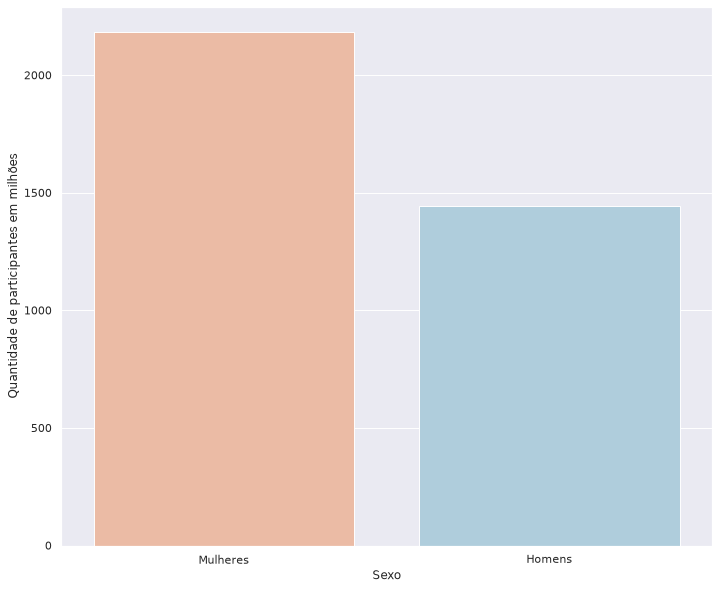

In [175]:
sns.set_theme(
    style='darkgrid',
    # palette='dark',
    rc = {
        'legend.loc': 'upper right',
    }
)
fig, ax = plt.subplots(dpi=70, figsize=(12, 10))

sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),
             palette="RdBu", ax=ax)

for c in ax.containers:
    for v in c:
        bar_height = v.get_height()
        x_value = v.get_x()
        text = "{:.1%}".format(bar_height/len(df))
ax.set_ylabel("Quantidade de participantes em milhões")
ax.set_xlabel("Sexo")

### Nota média por fatores sociais

/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1538710540.py:8: DeprecationWa

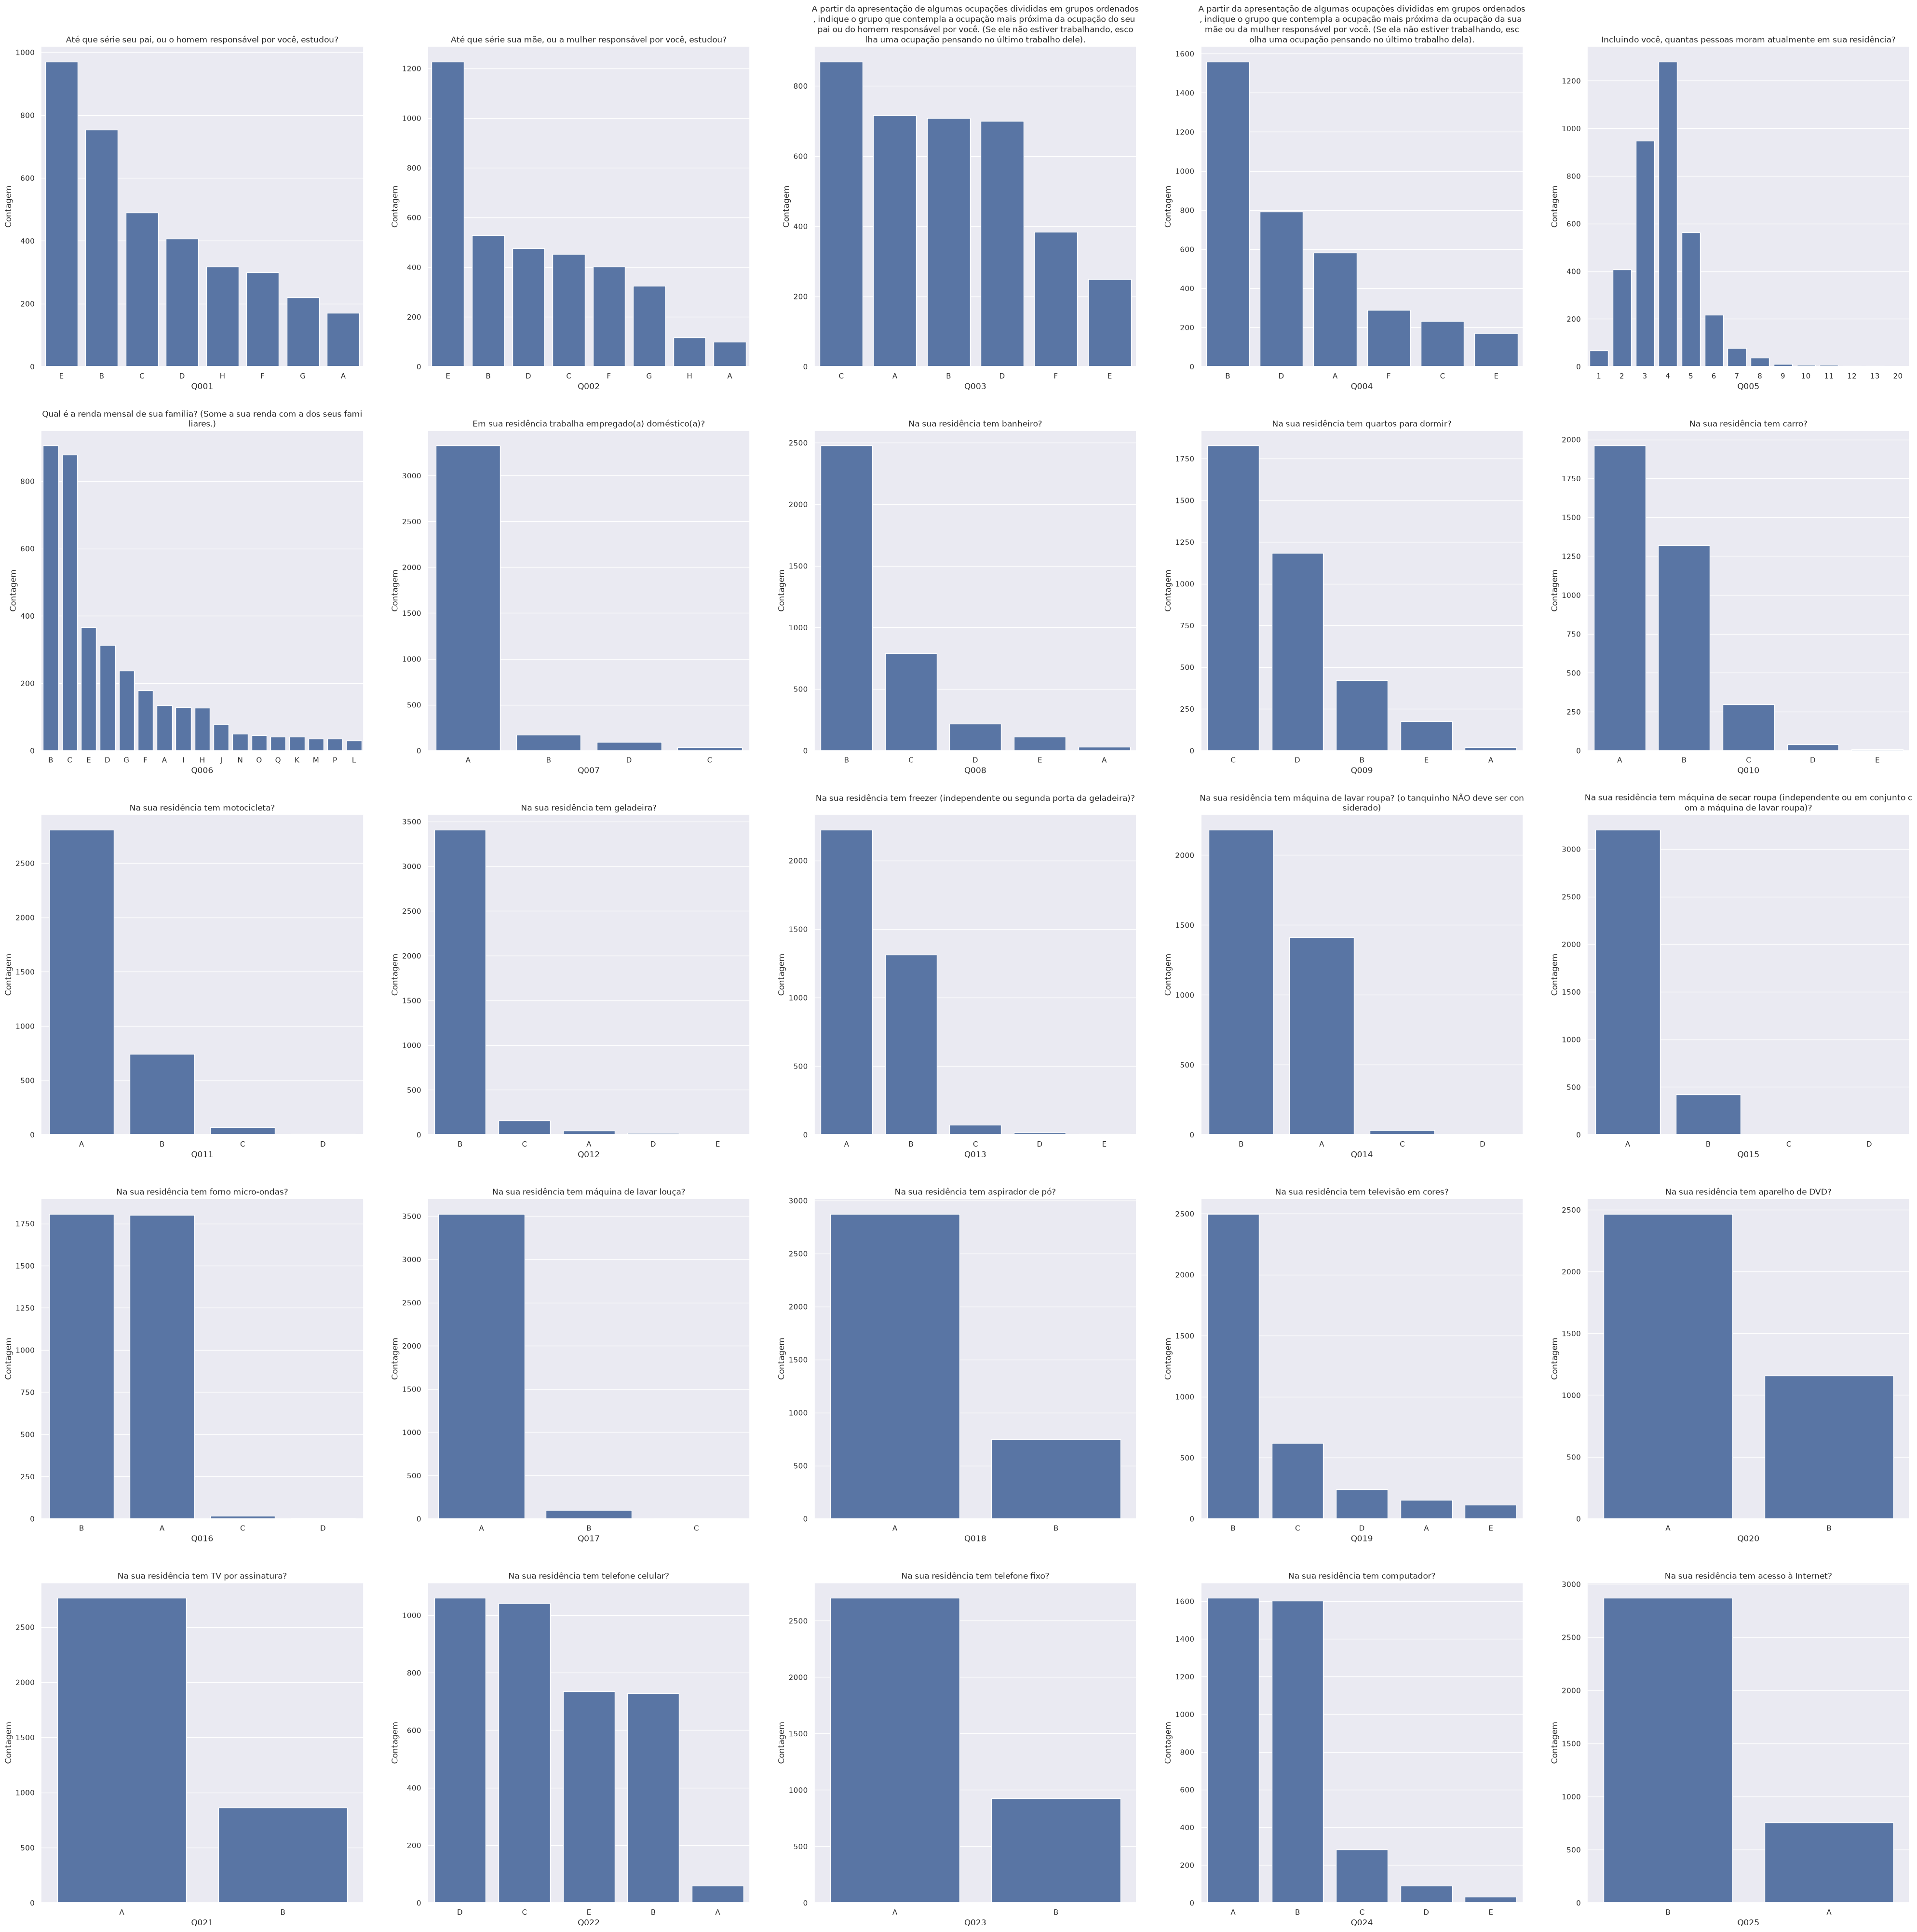

In [176]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('Q')]):
    counts = df[column].value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.index, y=counts, ax=ax)
    ax.set_ylabel('Contagem')
    title = descricoes.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Nota média por sexo, estado civil, raça e etc

/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/2013408085.py:8: DeprecationWa

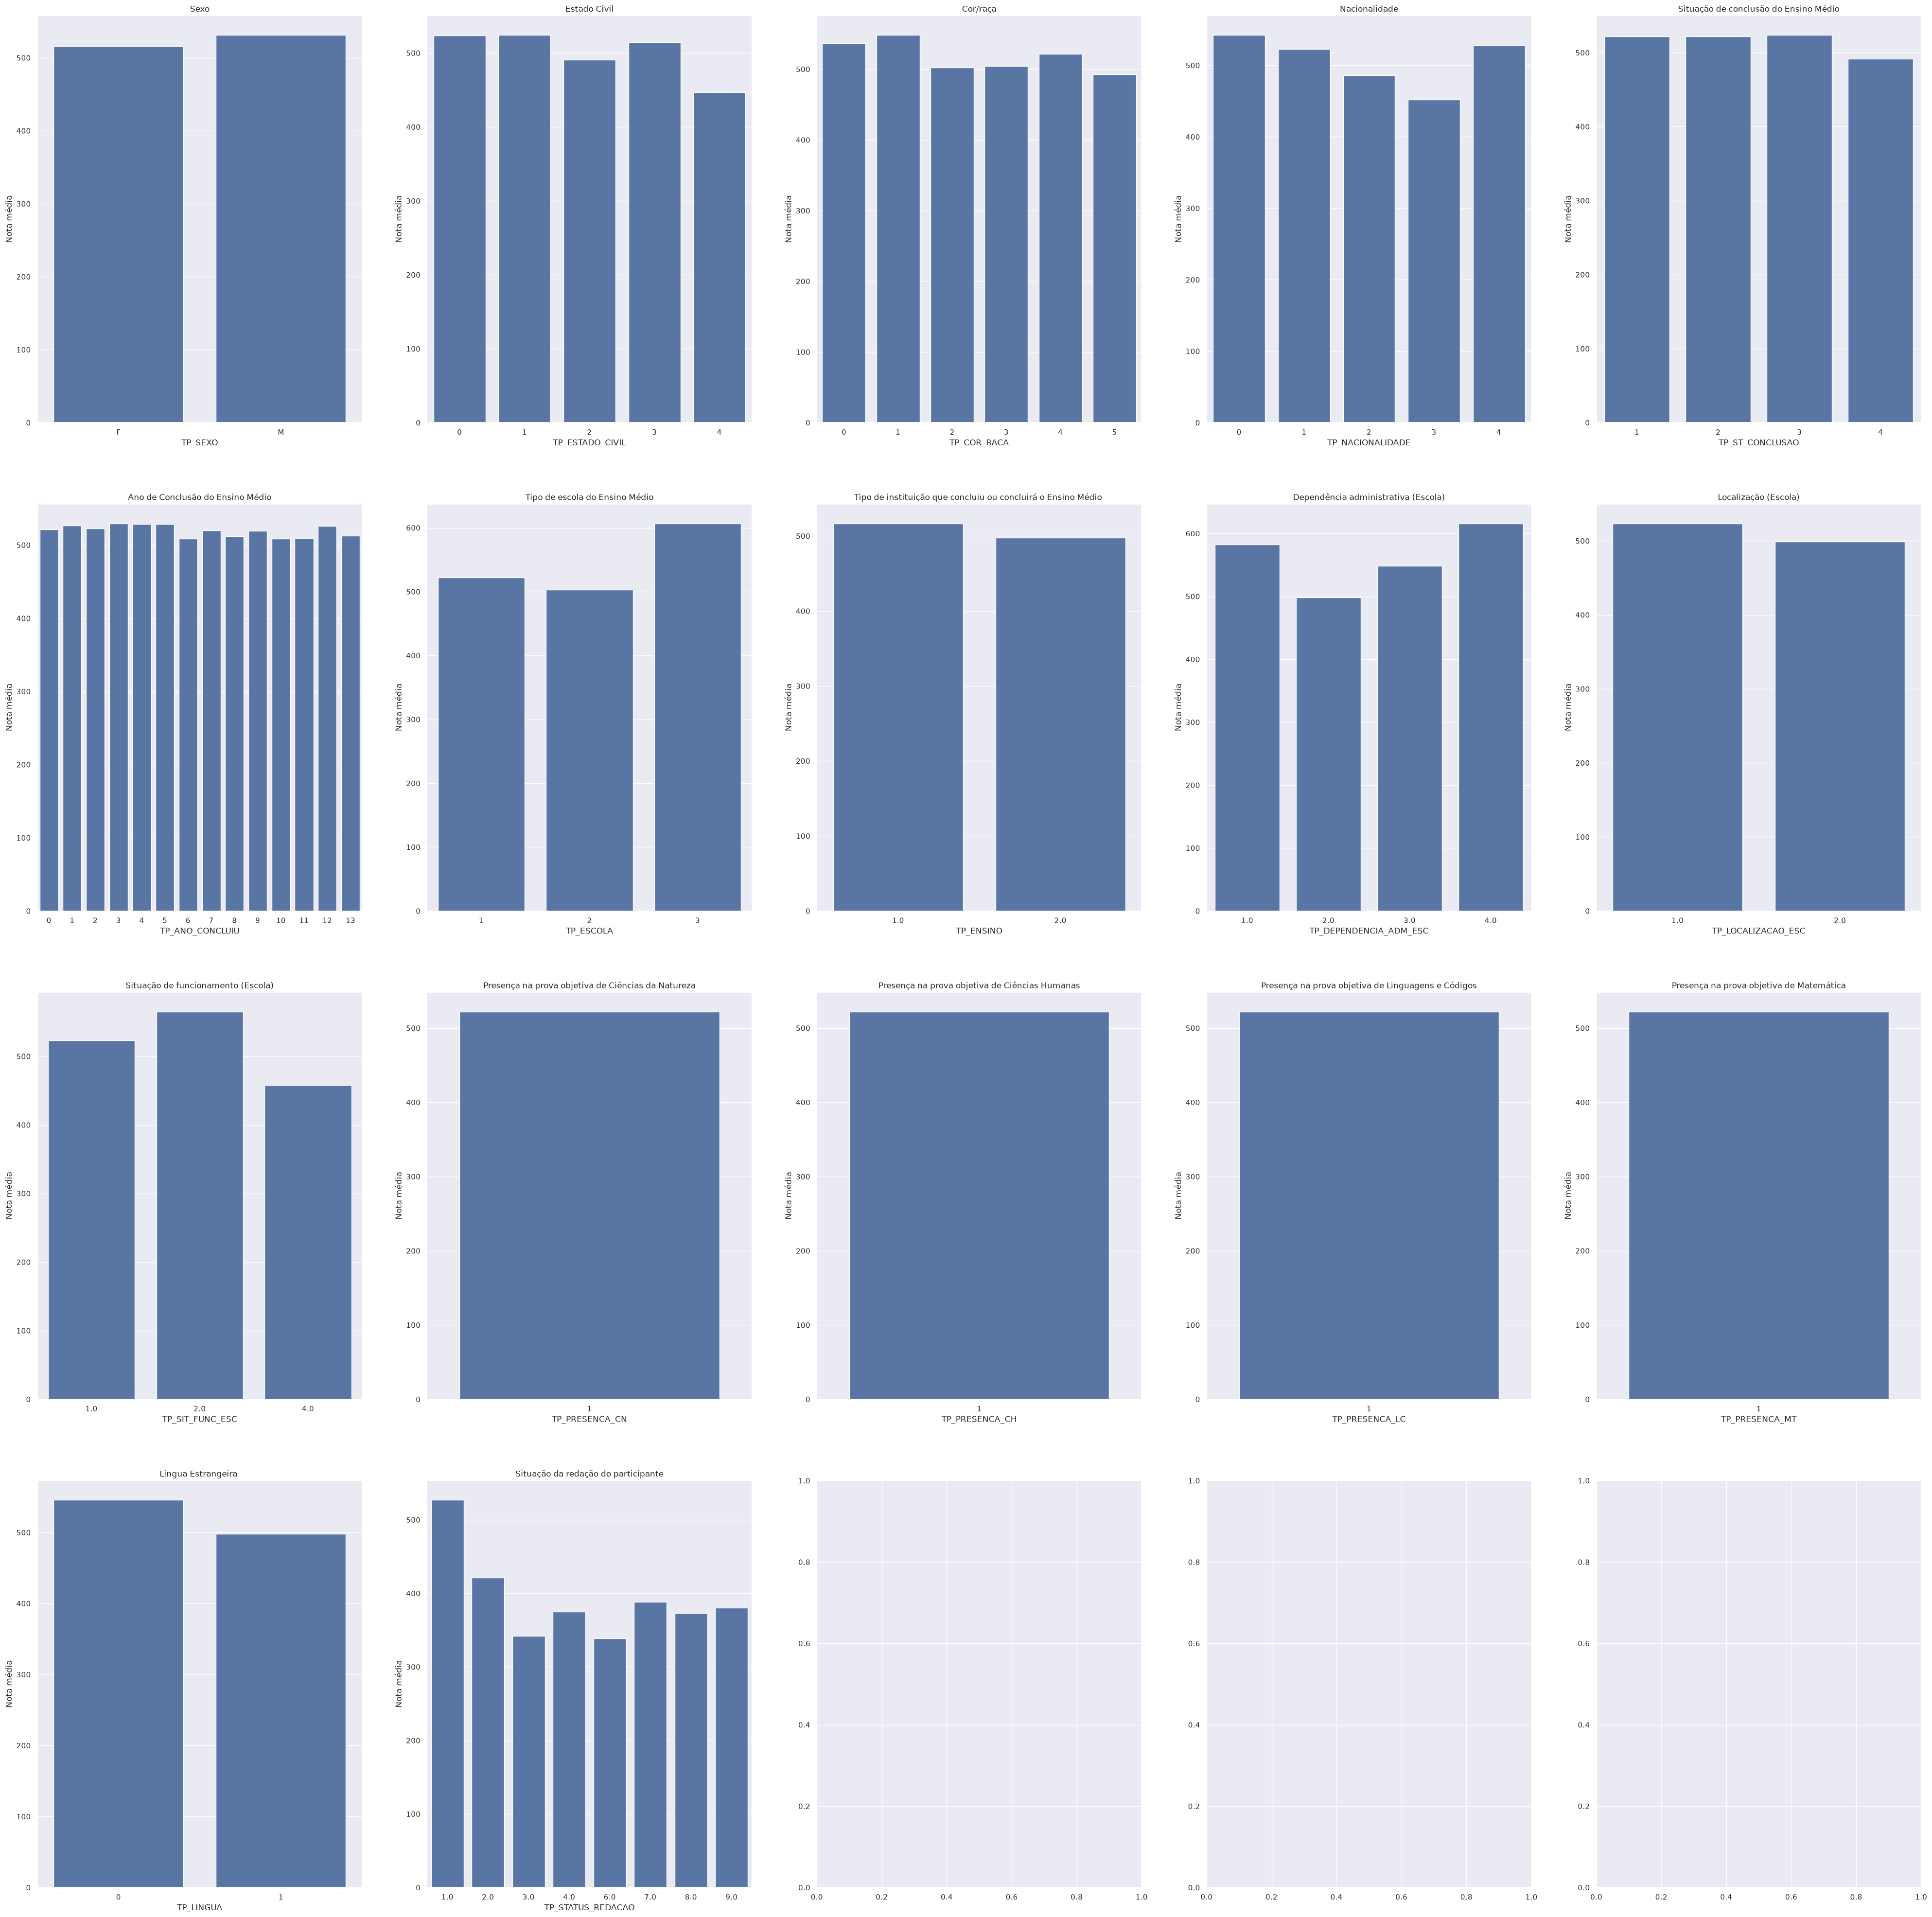

In [177]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(4,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('TP')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descricoes.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Nota média de treineiro e portadores de condições especiais

/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/3308060227.py:8: DeprecationWa

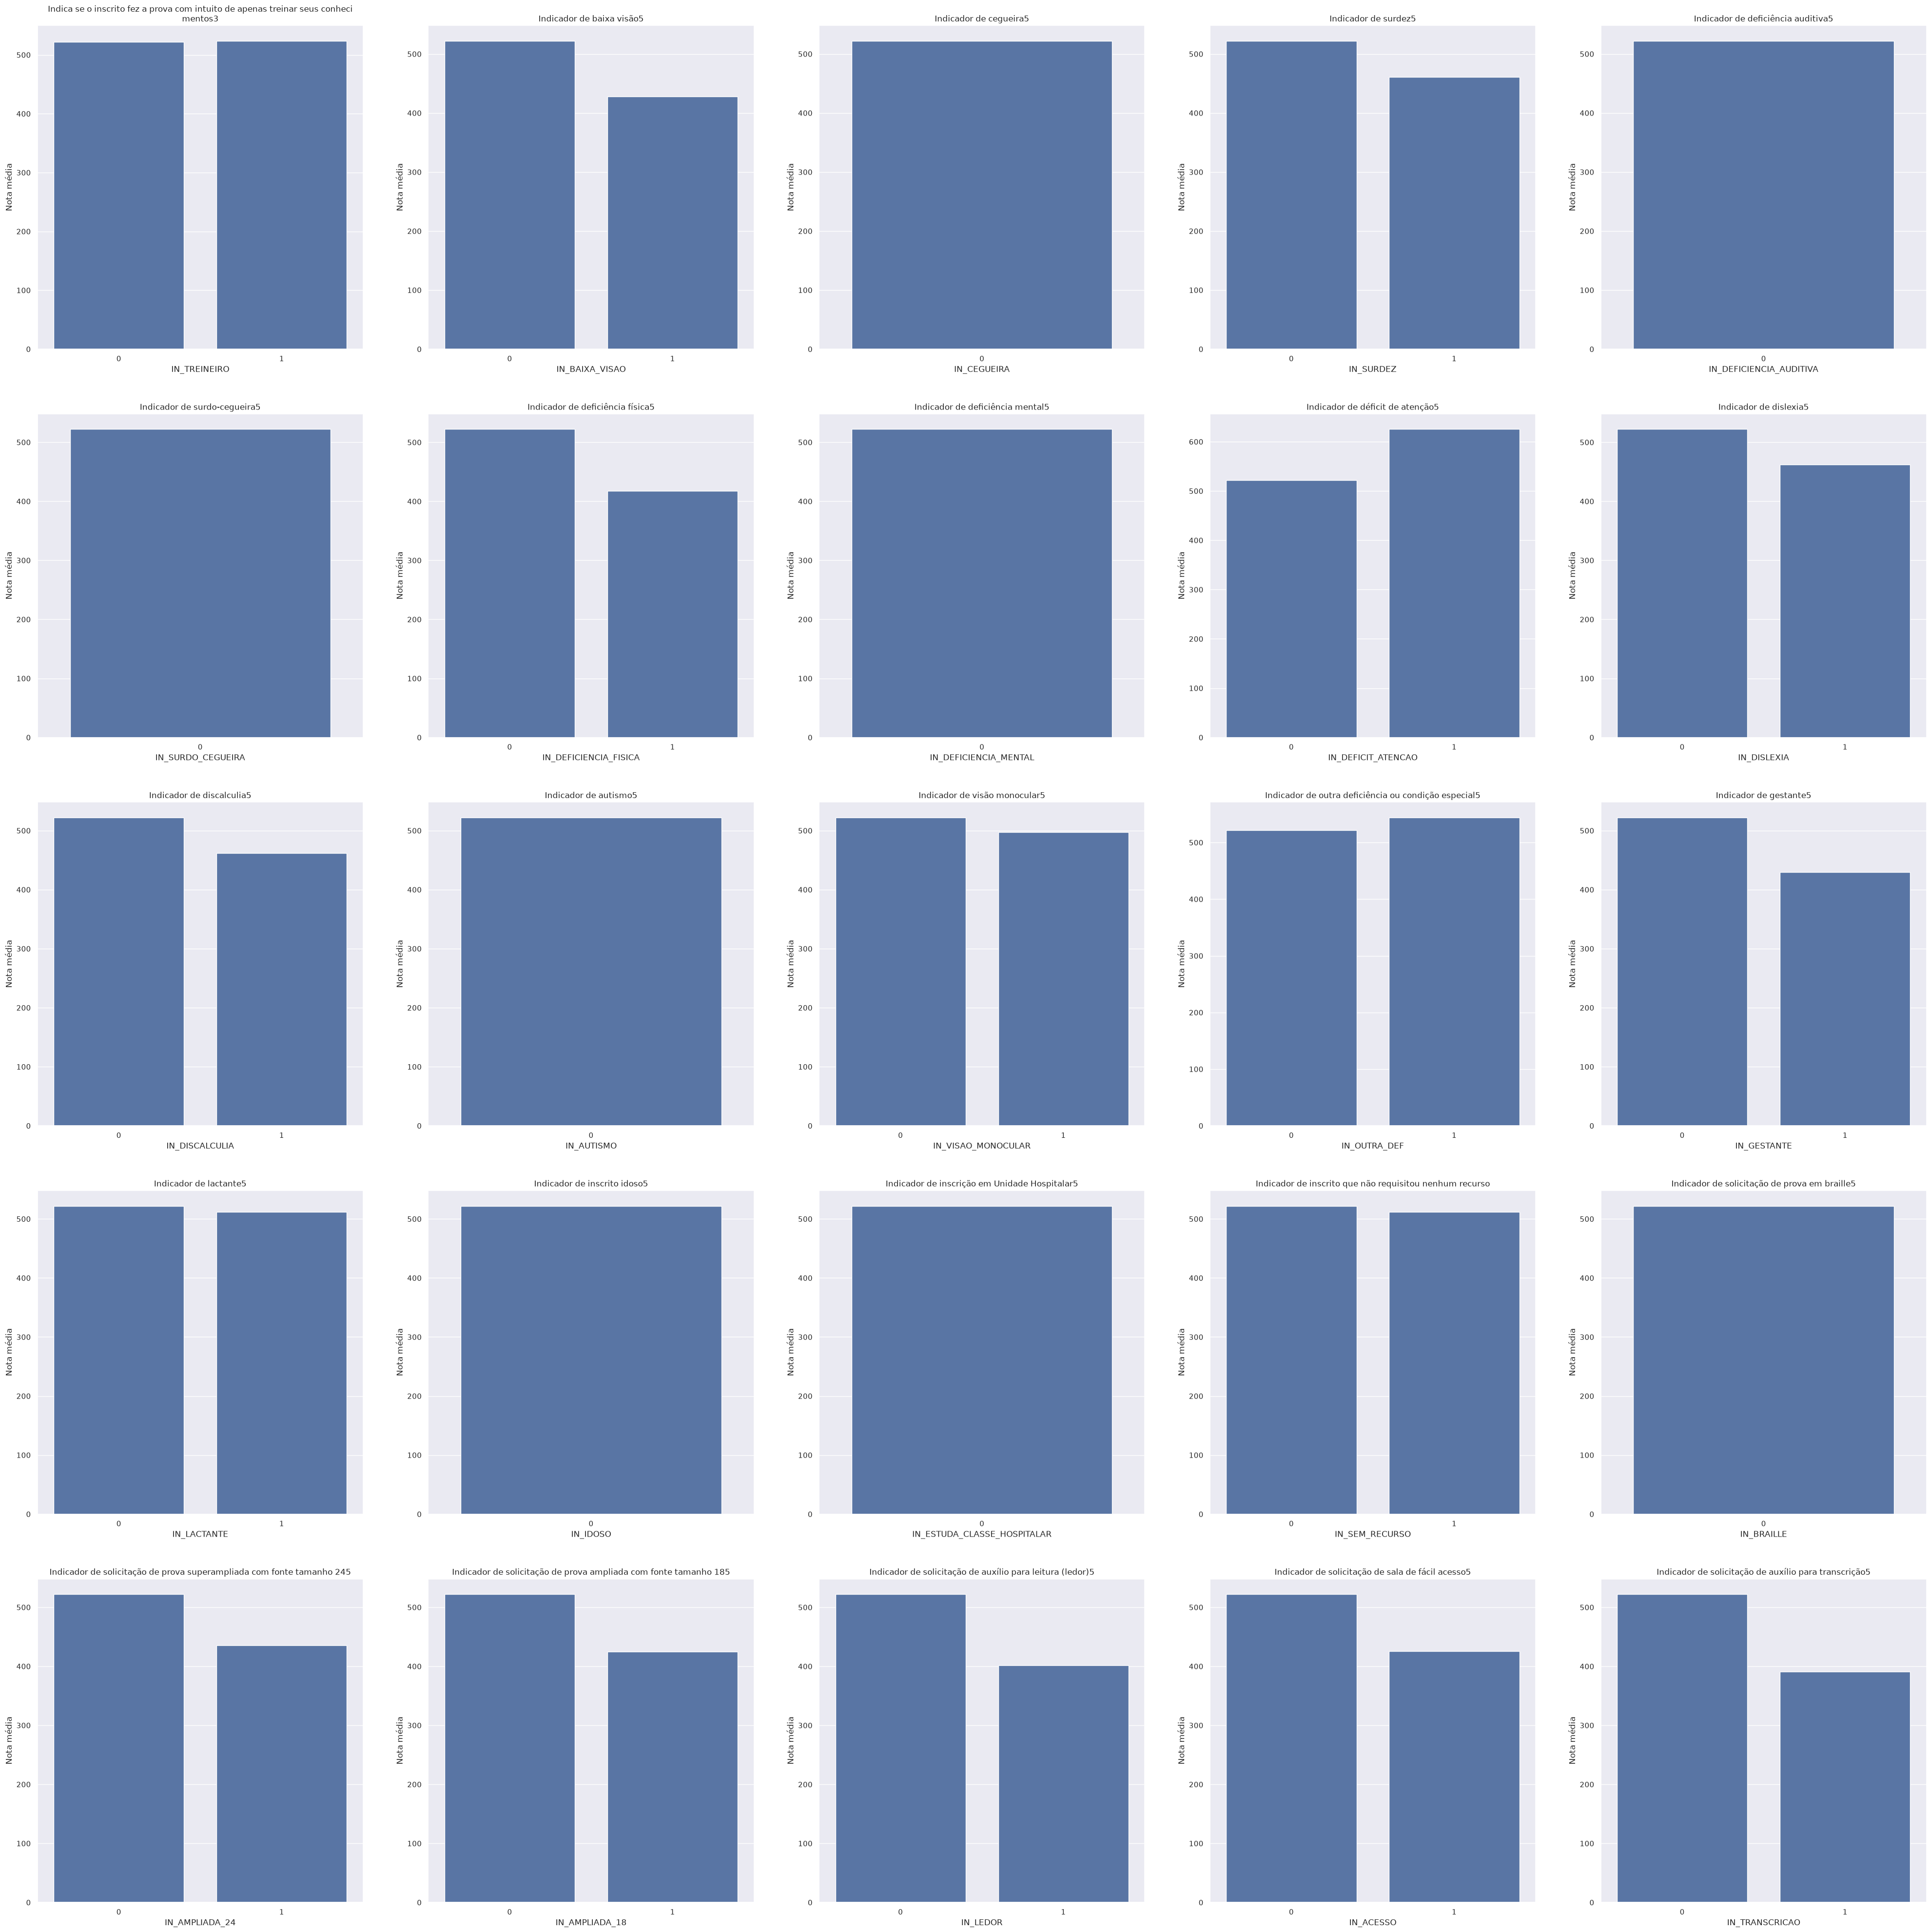

In [178]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descricoes.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

### Presença por Condições especiais

/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWarning: 'count' is passed as positional argument
  title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
/tmp/ipykernel_775506/1259293679.py:8: DeprecationWa

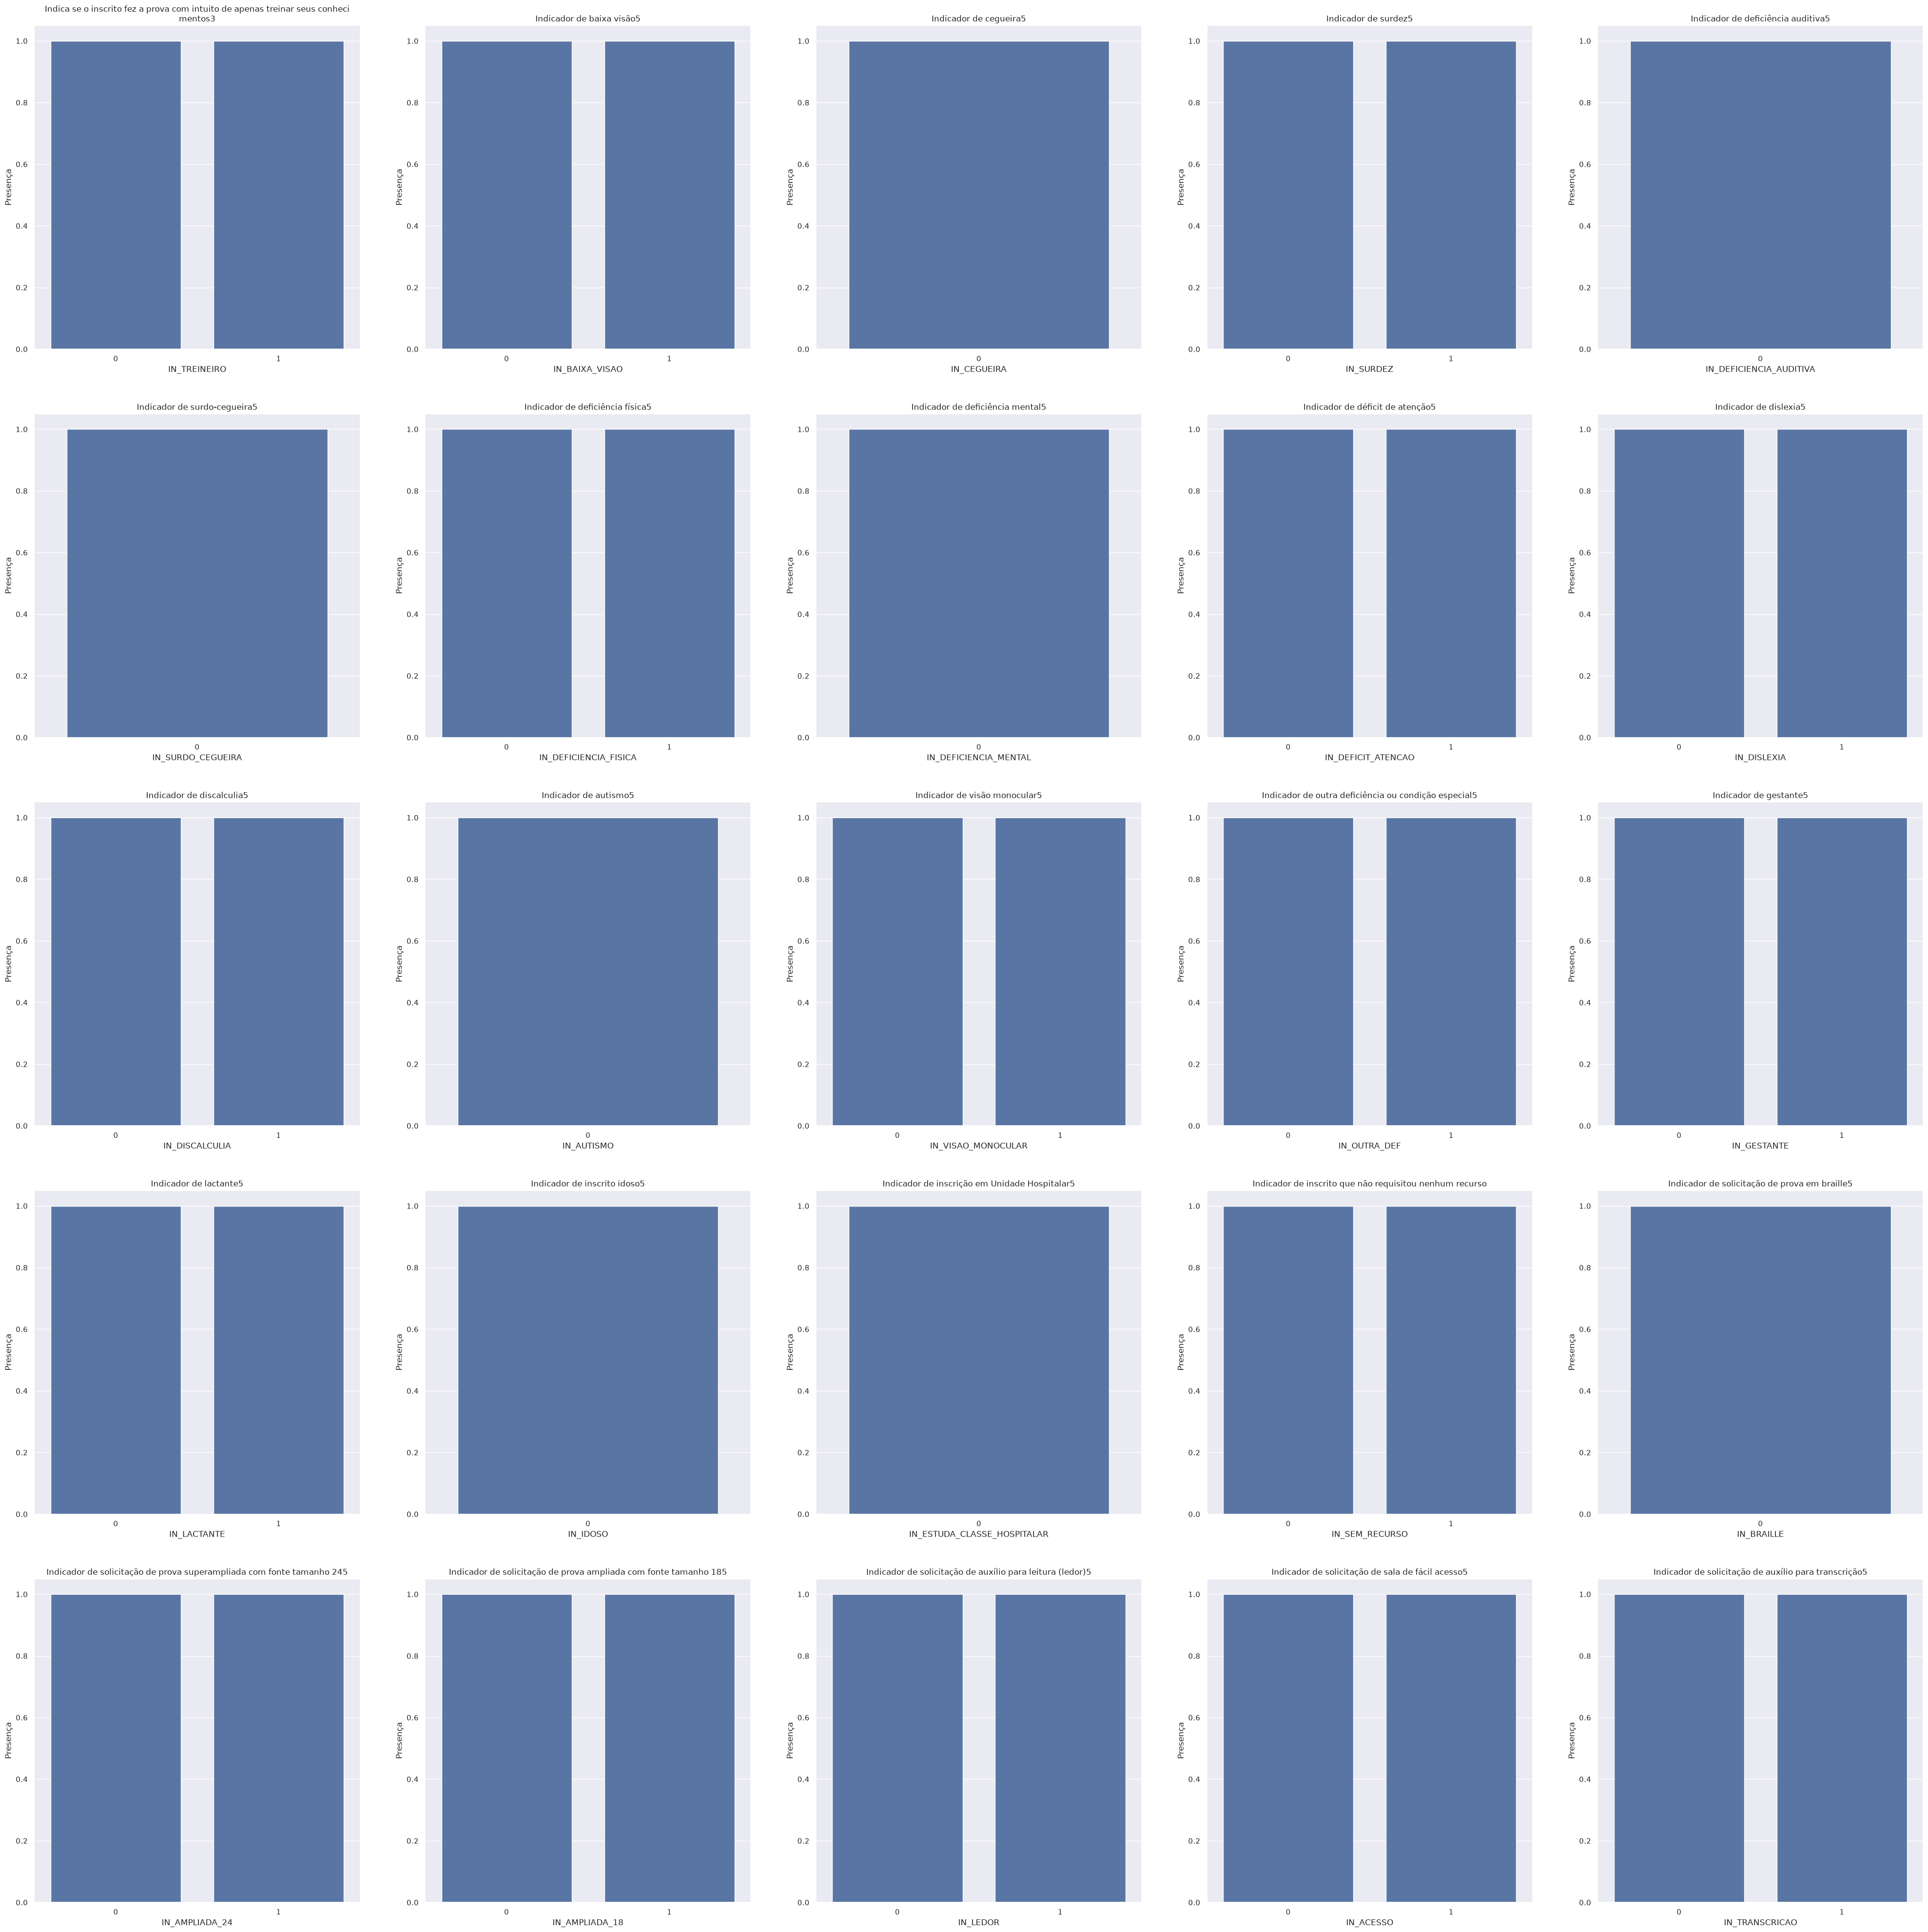

In [179]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('TP_PRESENCA_CN')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Presença')
    title = descricoes.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, 0, re.DOTALL)
    ax.set_title(title)

<Axes: xlabel='NU_IDADE', ylabel='nota_Media'>

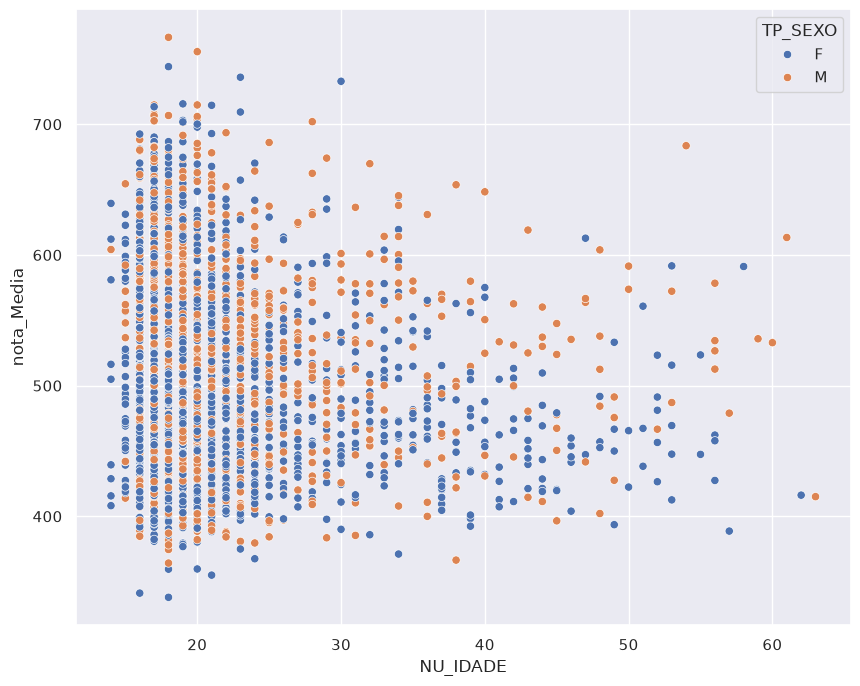

In [180]:
sns.scatterplot(data=df, x="NU_IDADE", y="nota_Media", hue='TP_SEXO')

## Modelo de regressão

In [181]:
nota_E = df[(df['nota_Media'] > 0) & (df['nota_Media'] <= 200)]
nota_D = df[(df['nota_Media'] > 200) & (df['nota_Media'] <= 400)]
nota_C = df[(df['nota_Media'] > 400) & (df['nota_Media'] <= 600)]
nota_B = df[(df['nota_Media'] > 600) & (df['nota_Media'] <= 800)]
nota_A = df[(df['nota_Media'] > 800) & (df['nota_Media'] <= 1000)]

Text(0.5, 1.0, 'Idade dos participantes do ENEM 2019')

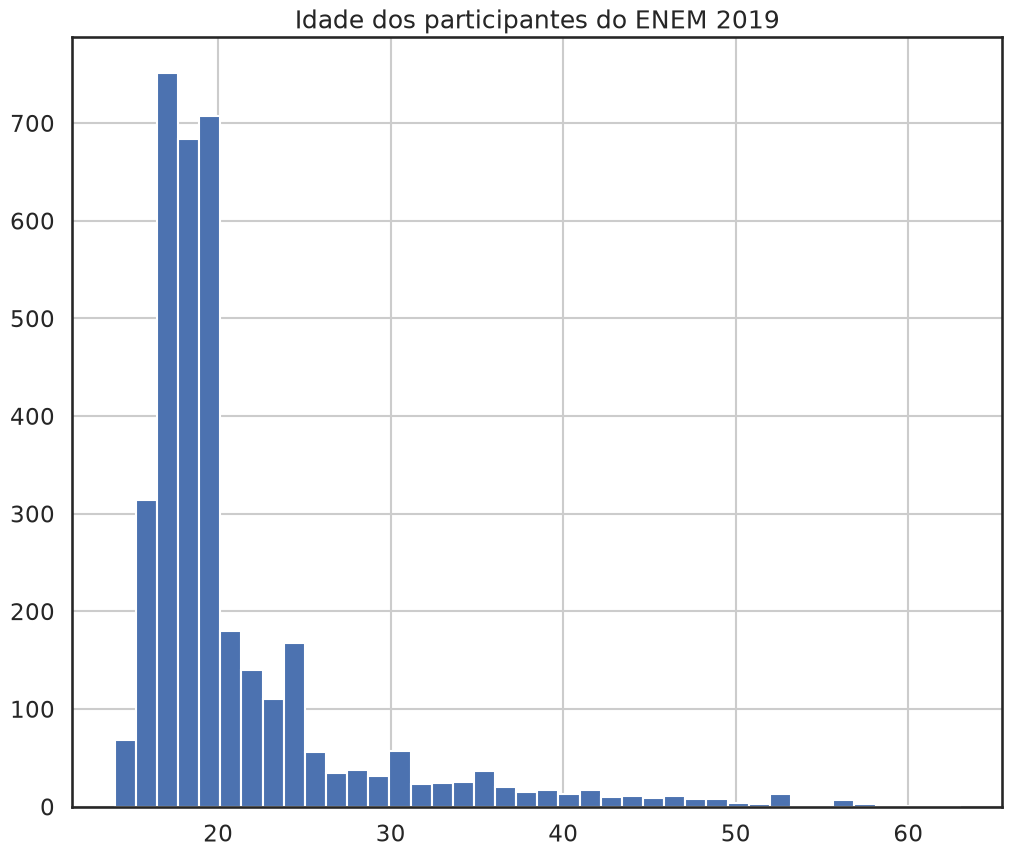

In [182]:
sns.set_theme(style="white", context="talk")
df["NU_IDADE"].hist(bins = 40, figsize = (12,10)).set_title("Idade dos participantes do ENEM 2019")

Text(0.5, 0, 'Etnia')

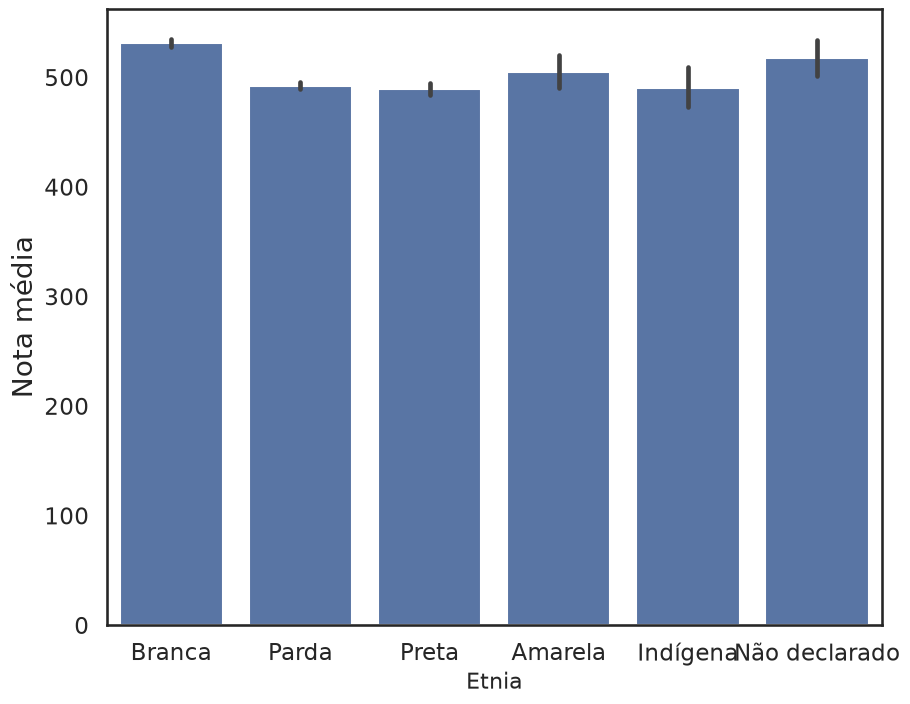

In [183]:
plt.rcParams['figure.figsize'] = (10, 8)
sns.barplot(data=df,
            x = df['TP_COR_RACA'].map({0:'Não declarado',1:'Branca',2:'Preta',3:'Parda',4:'Amarela',5:'Indígena'}), y = df['nota_Media']);
plt.ylabel('Nota média', fontsize=20)
plt.xlabel('Etnia', fontsize=16)

Text(0.5, 0, 'Modalidade')

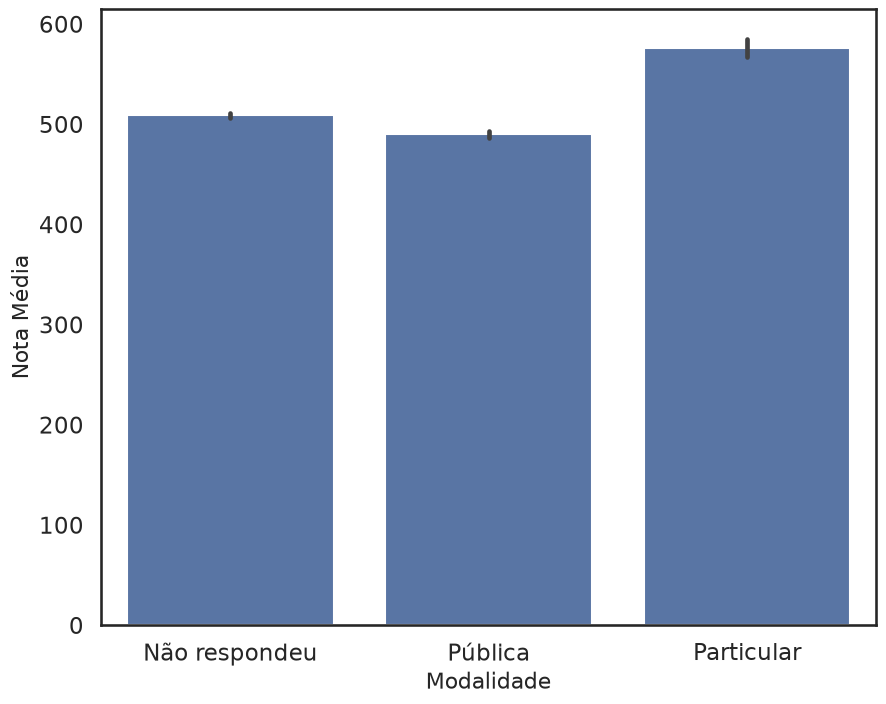

In [184]:
sns.barplot(data=df, x = df['TP_ESCOLA'].map({1:'Não respondeu',2:'Pública',3:'Particular'}), y = df['nota_Media'])
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Modalidade', fontsize=16)

/home/gakira/Programming/Python/Enem-2019/enem/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


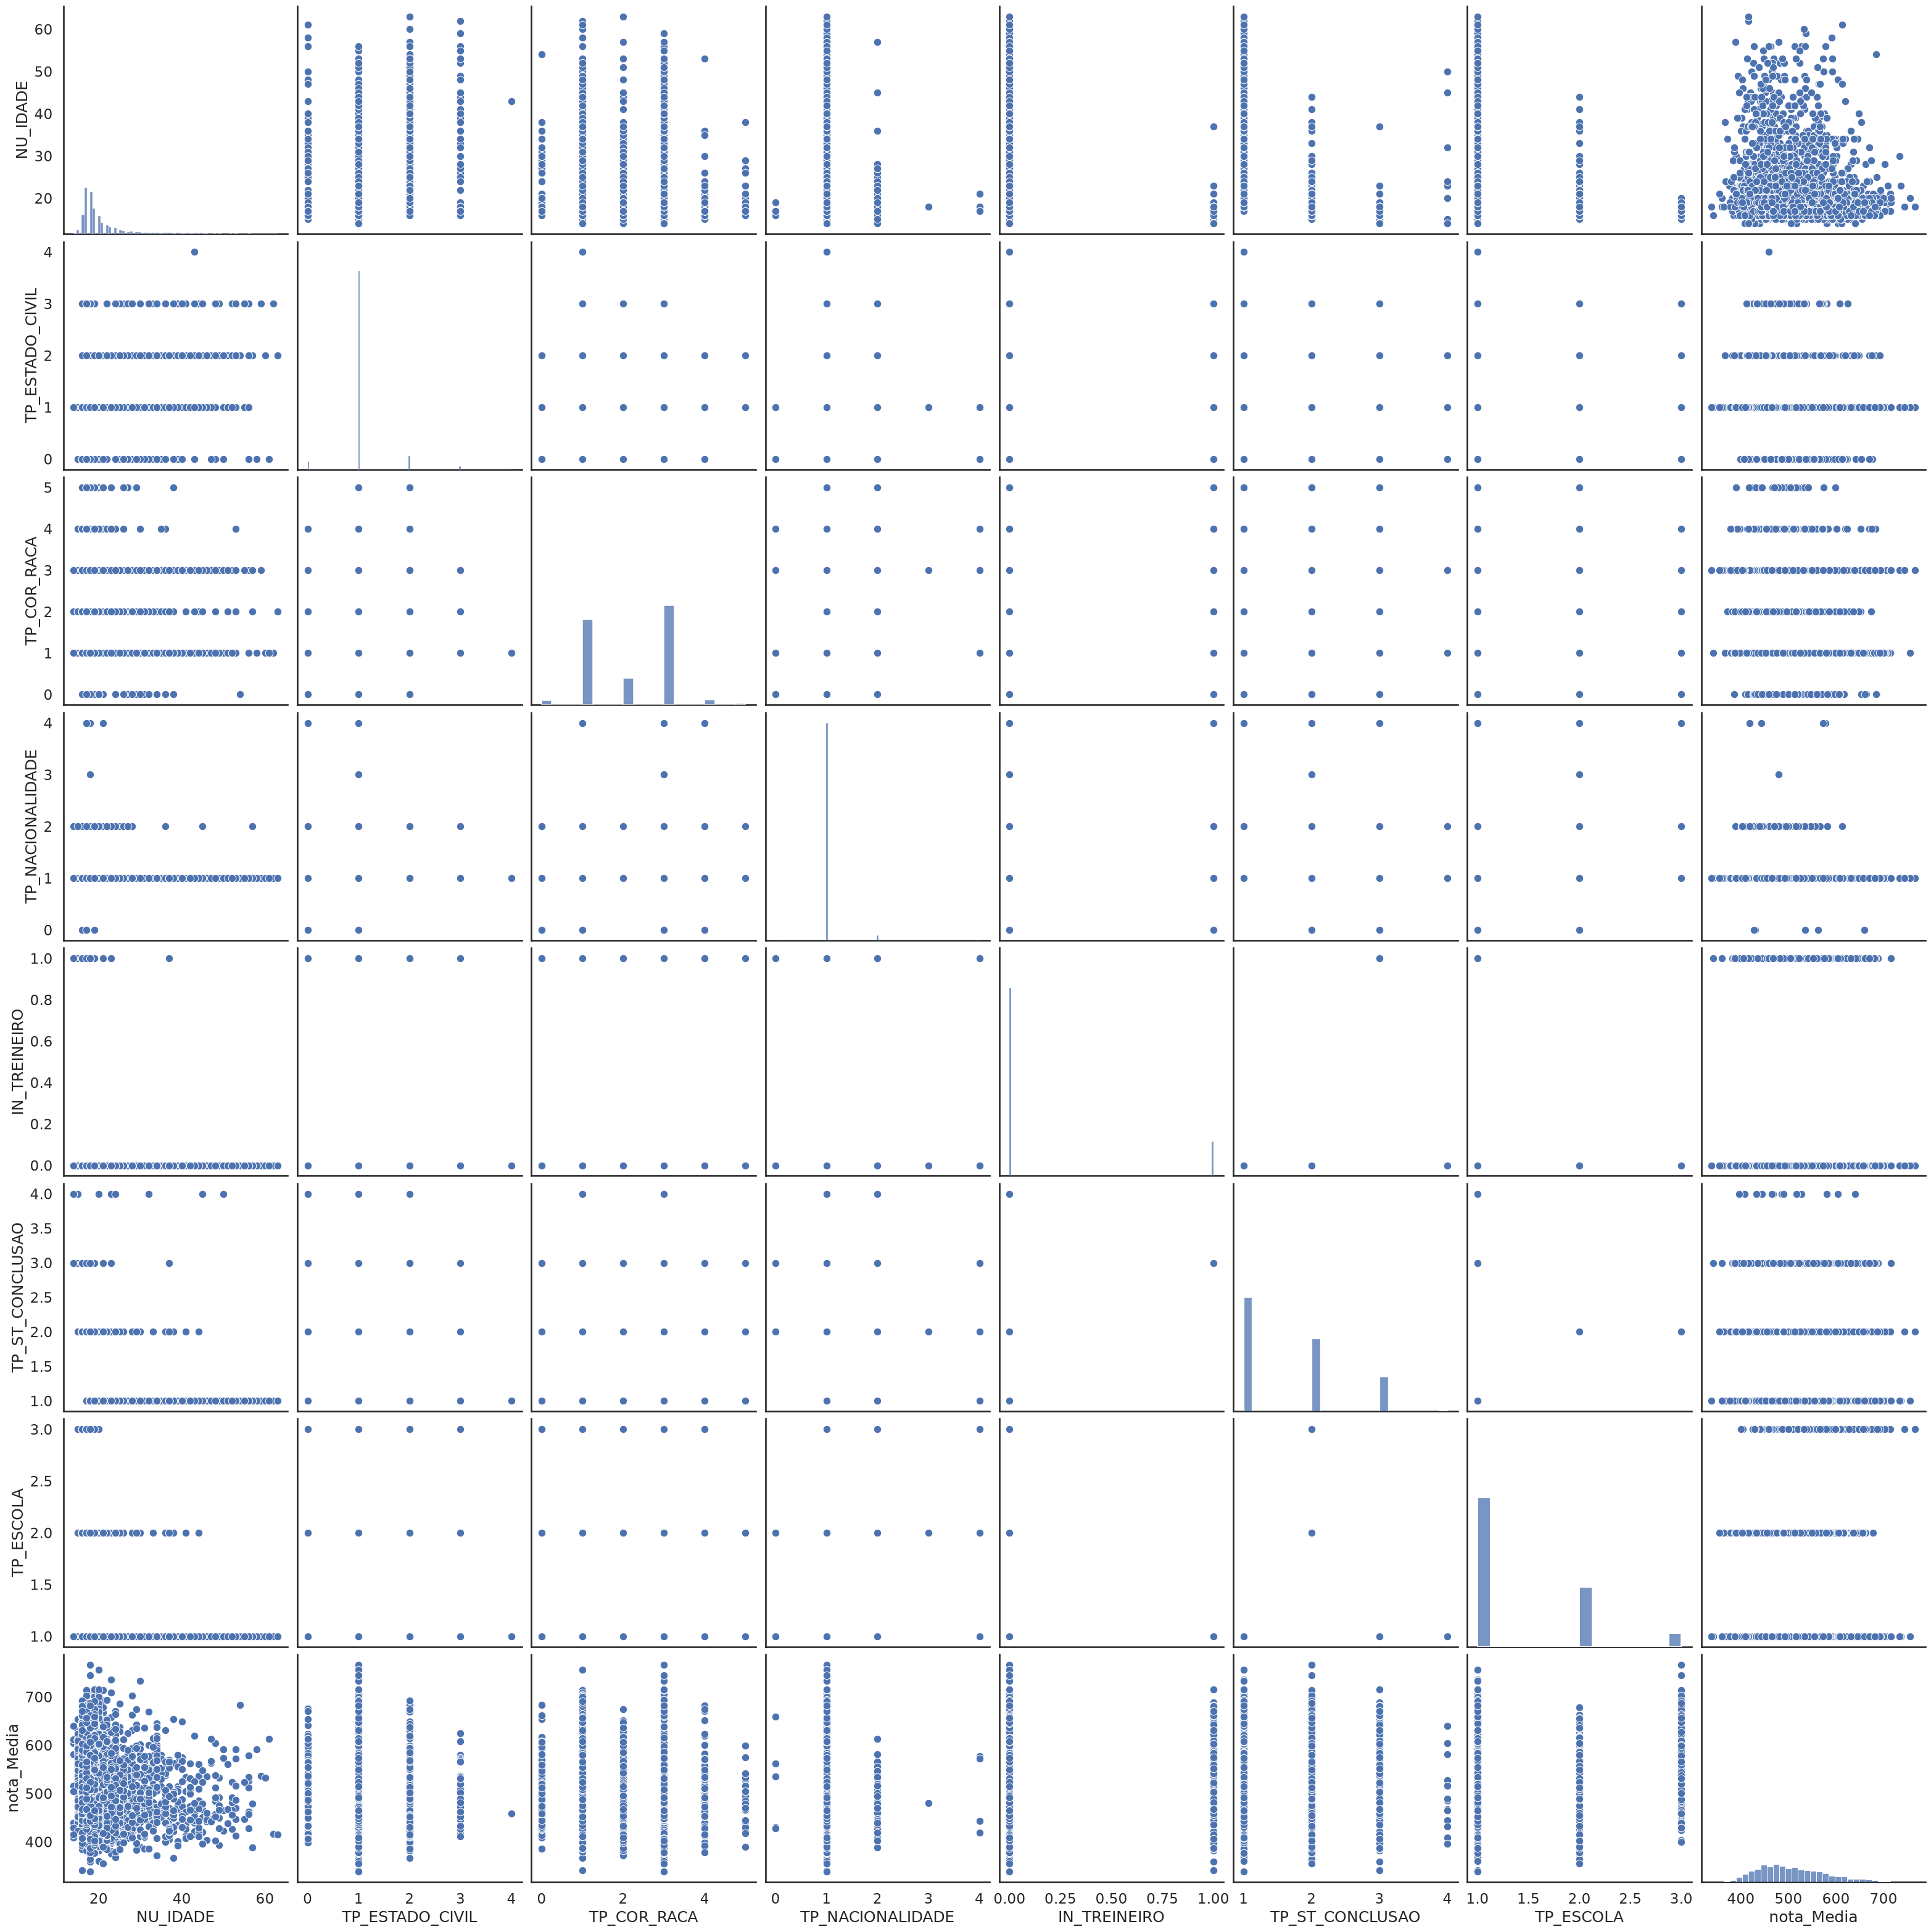

In [185]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

Text(0.5, 0, 'Idade')

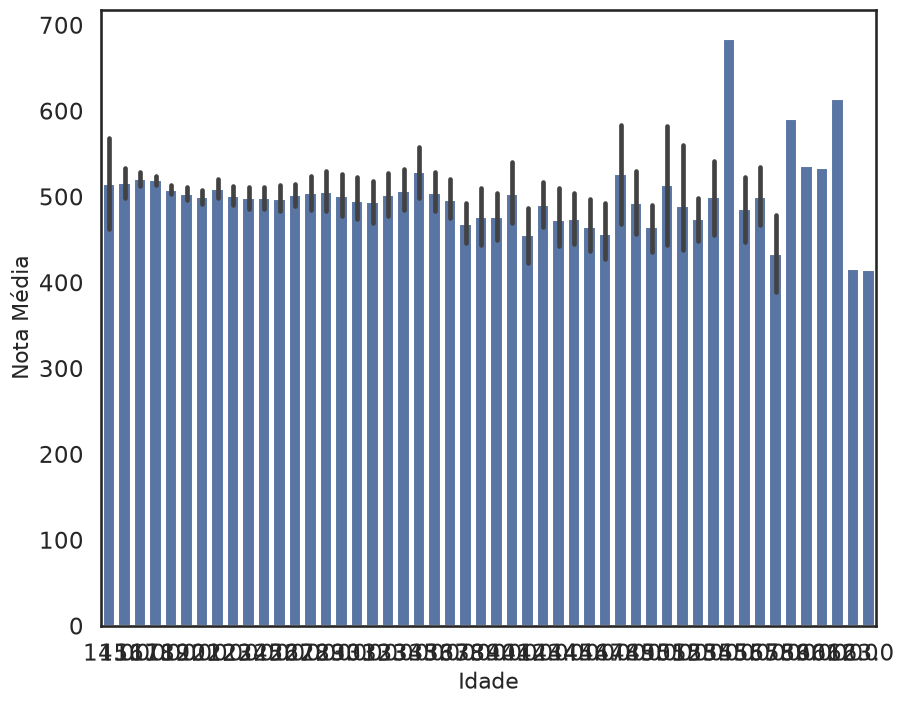

In [186]:
sns.barplot(data=df, x = 'NU_IDADE', y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Idade', fontsize=16)

Text(0.5, 0, 'Estado Civil')

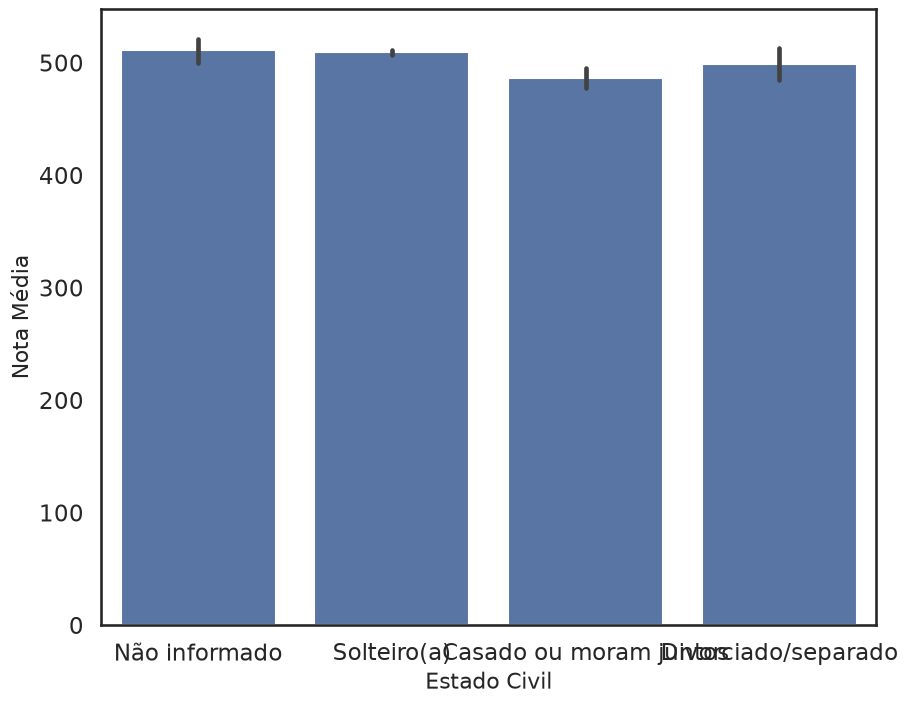

In [187]:
sns.barplot(data=df, x = df['TP_ESTADO_CIVIL'].map({0:'Não informado', 1:'Solteiro(a)', 2:'Casado ou moram juntos', 3:'Divorciado/separado'}), y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Estado Civil', fontsize=16)

Text(0, 0.5, 'Nota Média')

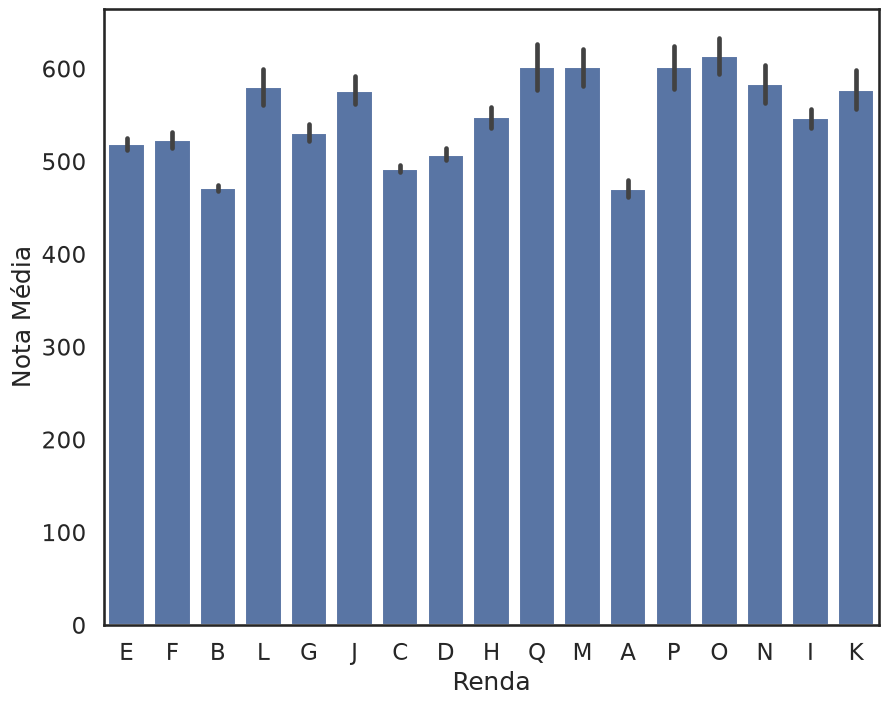

In [188]:
sns.barplot(data=df, x= 'Q006', y = 'nota_Media')
plt.xlabel('Renda')
plt.ylabel('Nota Média')

### Fazer só com as colunas numéricas

In [189]:
### Fazer isso só com as colunas numéricas
#sns.pairplot(dados.iloc[:, :10])

In [190]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(''), annot=True, fmt='.0%')
#IN_SEM_RECURSO

In [191]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(), annot=True, fmt='.0%')

# Treino Modelo 1

In [192]:
X = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [193]:
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.30, random_state=42)

In [194]:
reg = LinearRegression()
modelo1 = reg.fit(X_train, y_train)
y_pred = modelo1.predict(X_test)
reg.coef_

array([ -0.98629411,  -4.2759186 , -16.98272124, -20.12292241,
        -5.27248891,   5.24695931])

Cálculo de erros

In [195]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

4553.86713933461

In [196]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

54.987987754388804

In [197]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.04983239890611735

# Treino Modelo 2

In [198]:
train_size = int(len(df)*0.6)
X = df[['NU_IDADE', 'TP_COR_RACA', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.40, random_state=13)

In [200]:
reg = LinearRegression()
modelo2 = reg.fit(X_train, y_train)
y_pred = modelo2.predict(X_test)
reg.coef_

array([ -1.08222166, -16.02862123,  -5.9796982 ,   8.51837021])

Cálculo de erros

In [201]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

4798.2482617150345

In [202]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

56.513667657419774

In [203]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.0591400869853872

# Treino Modelo 3

In [204]:
train_size = int(len(df)*0.6)
#Q006
X = df[['NU_IDADE', 'TP_COR_RACA', 'IN_TREINEIRO']]
Y = df['nota_Media']

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=22)

In [206]:
reg = LinearRegression()
modelo3 = reg.fit(X_train, y_train)
y_pred = modelo3.predict(X_test)
reg.coef_

array([ -0.95270069, -15.96257207,  -3.99218184])

Cálculo de erros

In [207]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

4543.457772061235

In [208]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

54.916223466207036

In [209]:
#R2
r2 = r2_score(y_test, y_pred)
r2

0.0632990111390157

## Análise Exploratória de Dados

In [210]:
#?pd.DataFrame.describe
df.describe

<bound method NDFrame.describe of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
0     d7e73c5f-2db8-4089-9bee-d3a0e045f87f                  1100023   
1     668bf6e4-ddf7-4810-b31e-7d325e36de4d                  3106200   
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
3     baf409f9-ddc6-4e82-9a4b-b64b579cd105                  2506301   
4     9fd415ac-3421-44ce-810e-599545c3c025                  2304400   
...                                    ...                      ...   
4994  4815bdce-d10b-4050-b467-904352b053c6                  2111300   
4995  5481de45-09e9-4ee8-ab4f-55fd2a37d18b                  1302603   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   
4997  86ac2a4a-b02f-4432-9b14-a6c246cfa93c                  2924504   
4998  f5297507-d354-494e-b05c-3b8087ac71ae                  2610707   

     NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  NU_IDADE  \
0                  Ariquemes        

In [211]:
df.info

<bound method DataFrame.info of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
0     d7e73c5f-2db8-4089-9bee-d3a0e045f87f                  1100023   
1     668bf6e4-ddf7-4810-b31e-7d325e36de4d                  3106200   
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
3     baf409f9-ddc6-4e82-9a4b-b64b579cd105                  2506301   
4     9fd415ac-3421-44ce-810e-599545c3c025                  2304400   
...                                    ...                      ...   
4994  4815bdce-d10b-4050-b467-904352b053c6                  2111300   
4995  5481de45-09e9-4ee8-ab4f-55fd2a37d18b                  1302603   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   
4997  86ac2a4a-b02f-4432-9b14-a6c246cfa93c                  2924504   
4998  f5297507-d354-494e-b05c-3b8087ac71ae                  2610707   

     NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  NU_IDADE  \
0                  Ariquemes          

/home/gakira/Programming/Python/Enem-2019/enem/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


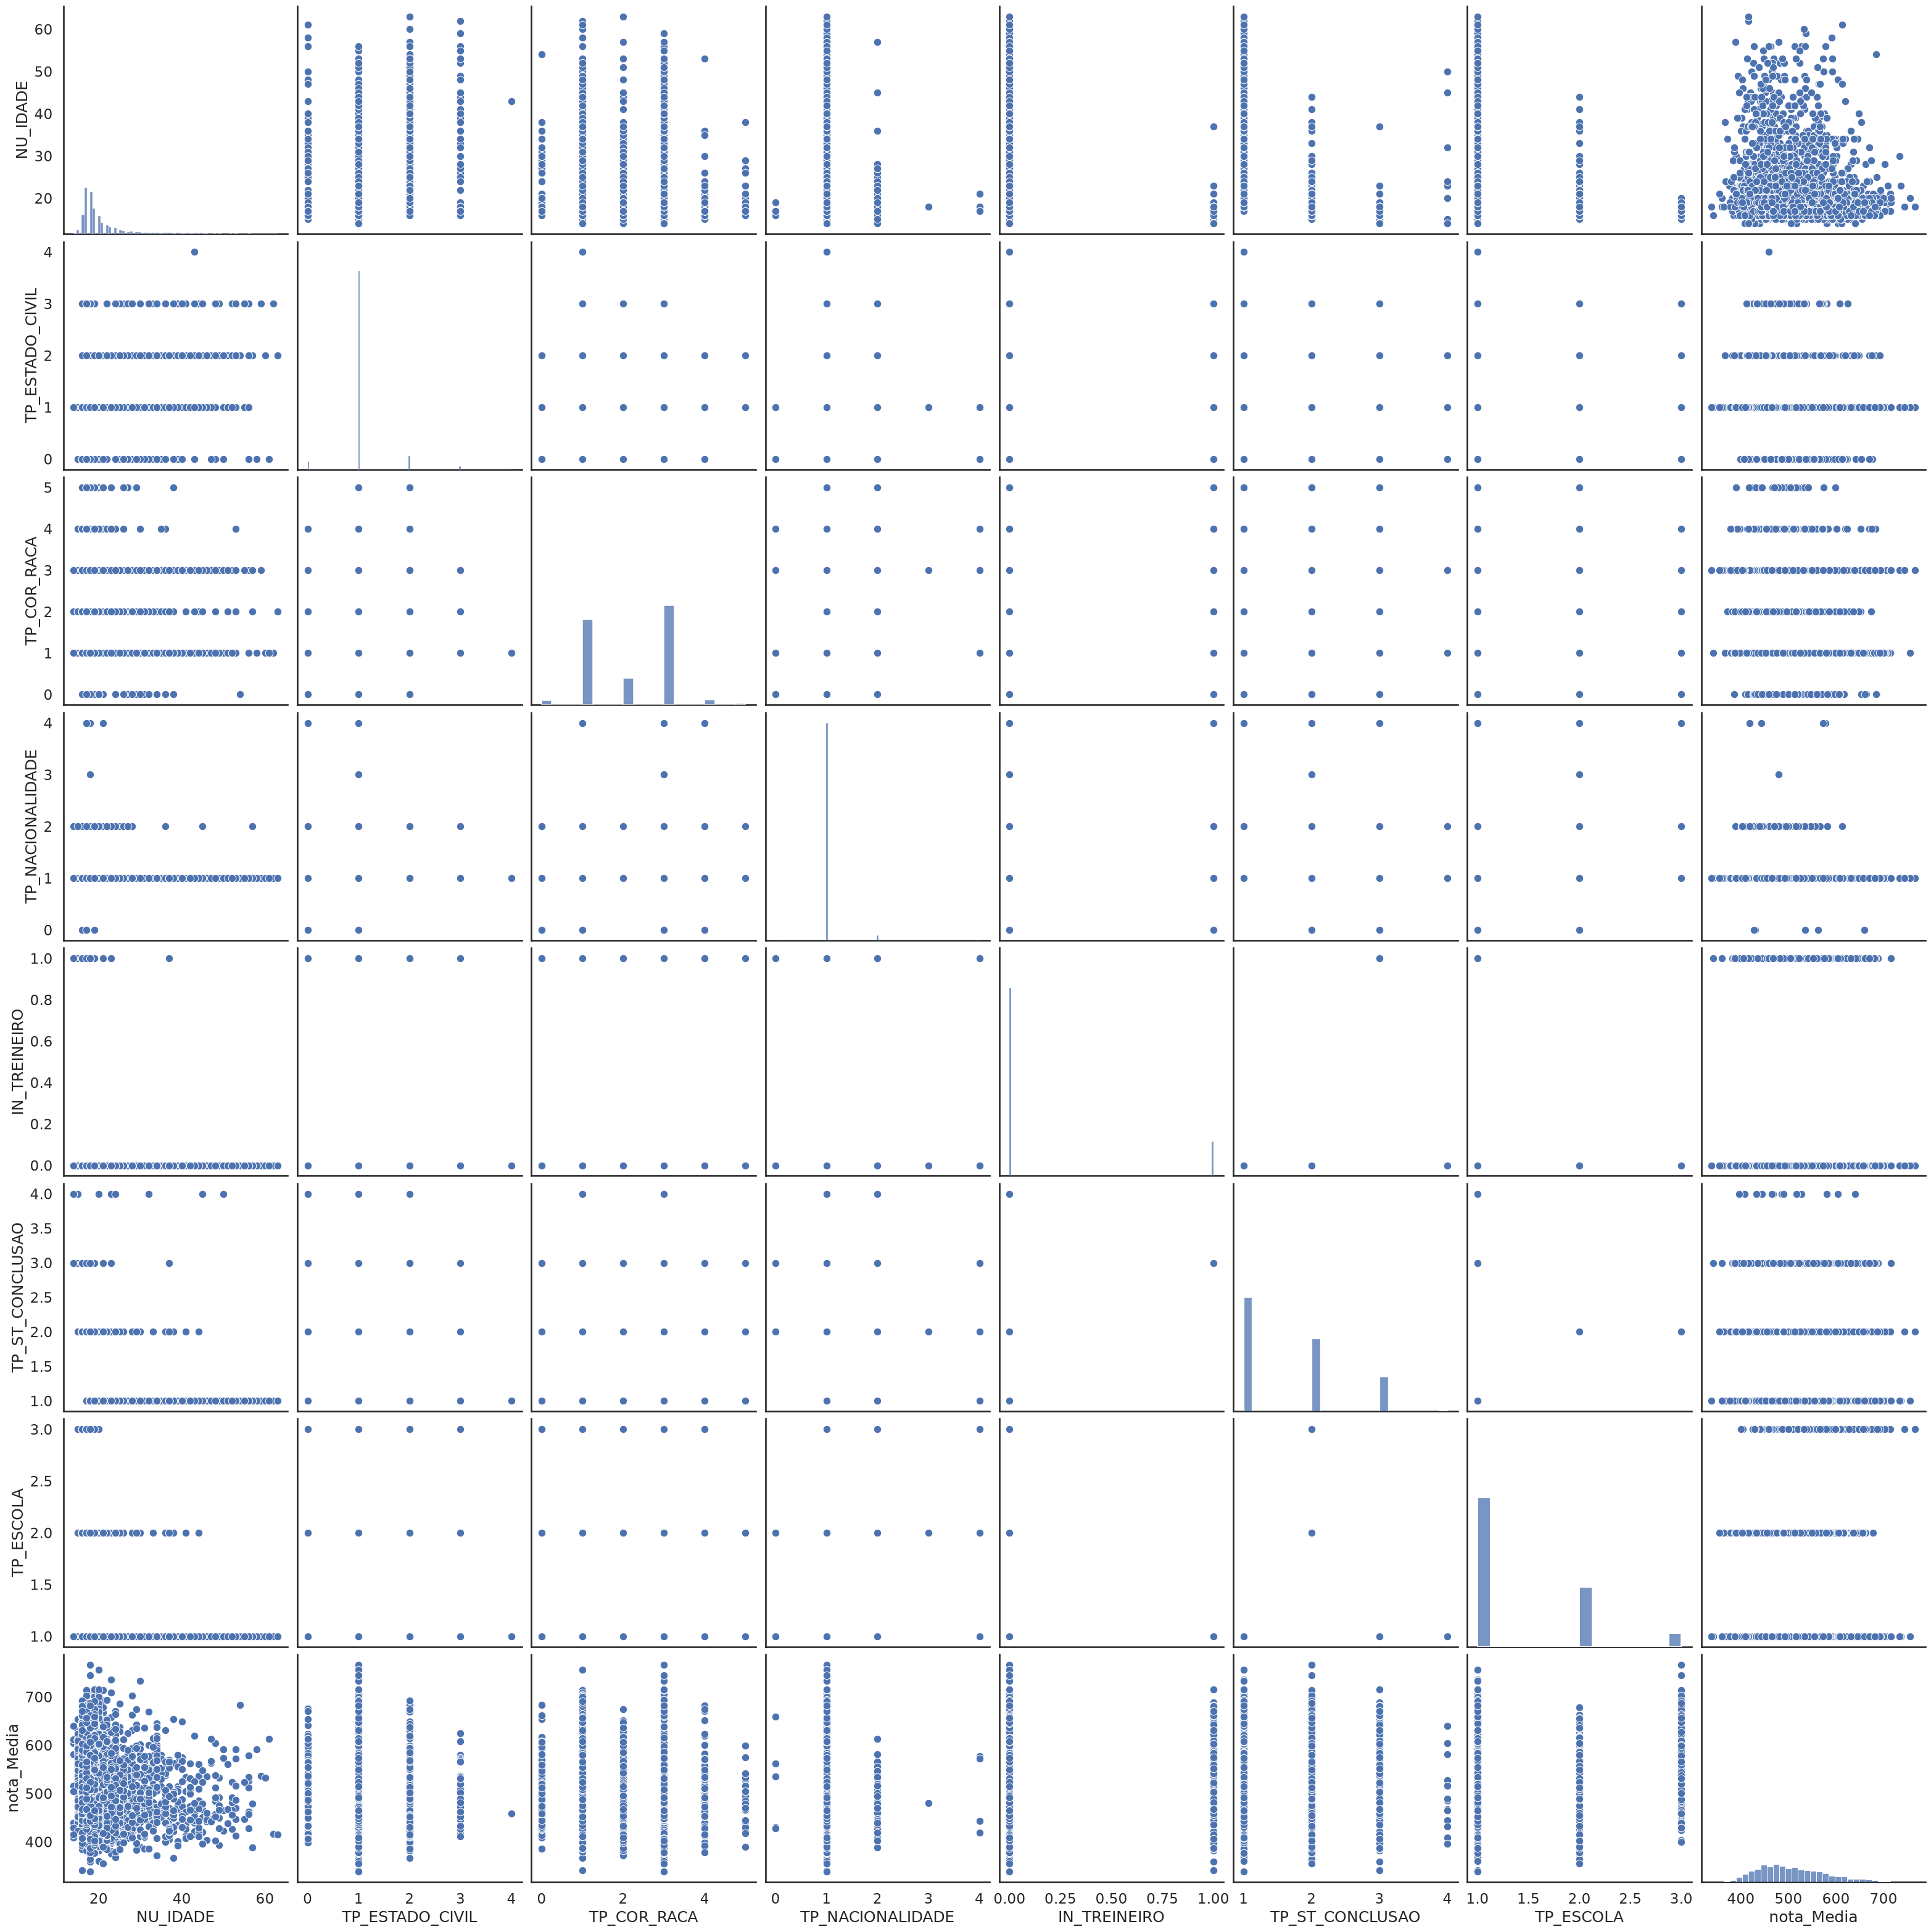

In [212]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

## Treino de modelo

### Regressão Linear